# 23. Pick a Reference Timestamp for Population Counting

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

The goal is to find **one fixed second** where the camera is zoomed in on the Mushroom vent with worms clearly visible. That timestamp will be used to extract one consistent frame per video across the full dataset.

**Instructions:**
1. Run **Cell 1** — it pre-extracts frames every 5 seconds across the full video (~2 min)
2. Run **Cell 2** — drag the slider to scrub through the video and find the best frame
3. Note the timestamp shown above the frame — plug it into `24_count_timeseries.ipynb`

</span>

In [6]:
import subprocess
from pathlib import Path
import matplotlib.image as mpimg

# ── Configuration ──────────────────────────────────────────────────
# Using a video confirmed to have the Mushroom vent zoom
# (had 15 worm detections in round 1 verification)
REFERENCE_VIDEO = Path(
    "/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/"
    "2024/10/01/CAMHDA301-20241001T091500.mp4"
)
STEP_SEC           = 5
VIDEO_DURATION_SEC = 1500  # ~25 min
CACHE_DIR          = Path("./timestamp_cache")
# ──────────────────────────────────────────────────────────────────

CACHE_DIR.mkdir(exist_ok=True)
timestamps = list(range(0, VIDEO_DURATION_SEC, STEP_SEC))

print(f"Pre-extracting {len(timestamps)} frames (every {STEP_SEC}s) ...")
print("Skipping frames already cached.\n")

for i, t in enumerate(timestamps):
    out = CACHE_DIR / f"frame_{t:05d}.png"
    if out.exists():
        continue
    subprocess.run(
        ["ffmpeg", "-y", "-ss", str(t), "-i", str(REFERENCE_VIDEO),
         "-frames:v", "1", "-q:v", "2", str(out)],
        capture_output=True, timeout=30,
    )
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(timestamps)} done ...")

frame_cache = {}
for t in timestamps:
    p = CACHE_DIR / f"frame_{t:05d}.png"
    if p.exists():
        frame_cache[t] = mpimg.imread(str(p))

print(f"\nCached {len(frame_cache)} frames. Run Cell 2 to open the slider.")

Pre-extracting 300 frames (every 5s) ...
Skipping frames already cached.



  50/300 done ...


  100/300 done ...


  150/300 done ...


  200/300 done ...


  250/300 done ...


  300/300 done ...



Cached 180 frames. Run Cell 2 to open the slider.


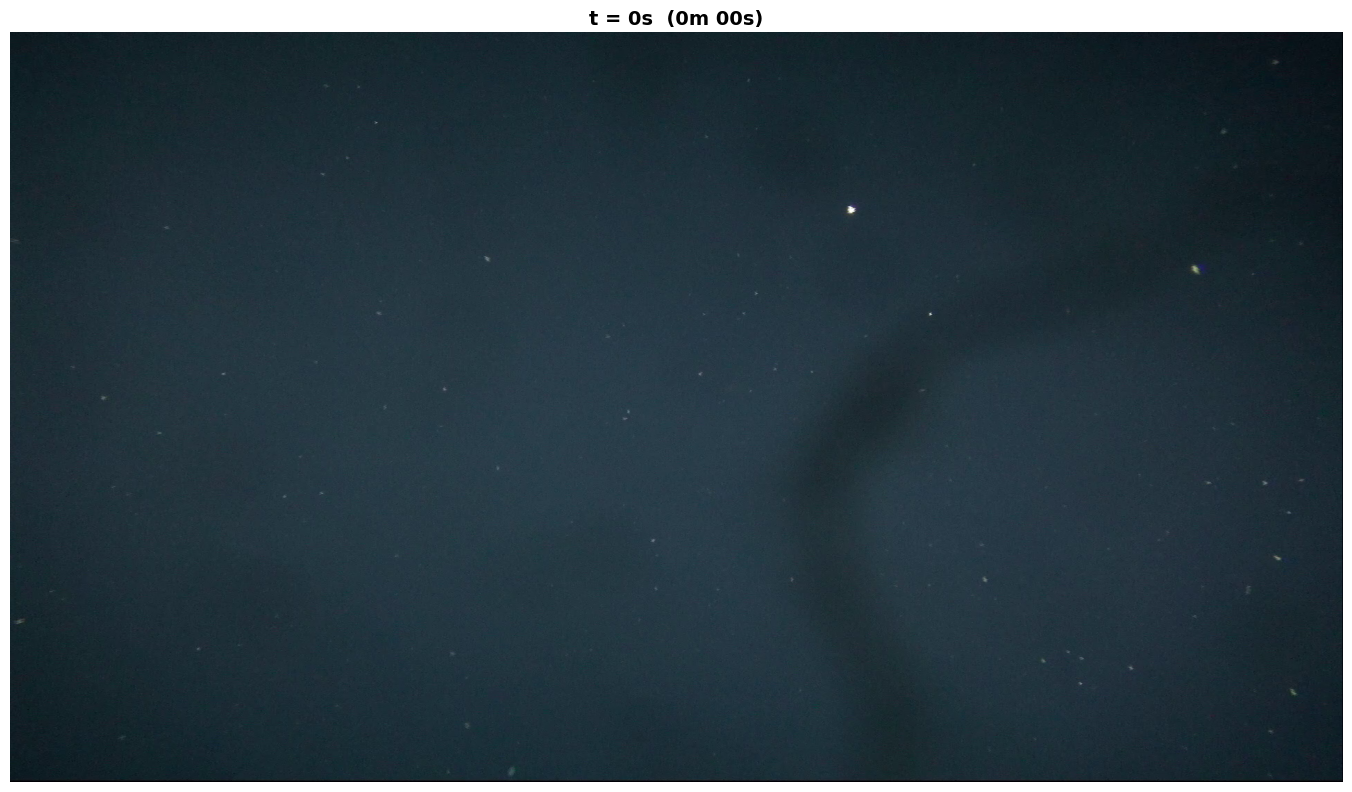

  REFERENCE_TIMESTAMP = 0


interactive(children=(SelectionSlider(description='Time:', layout=Layout(width='900px'), options=(('0m 00s  (0…

In [7]:
%matplotlib inline
import ipywidgets as widgets
import matplotlib.pyplot as plt
from ipywidgets import interact

sorted_times = sorted(frame_cache.keys())

@interact(
    t=widgets.SelectionSlider(
        options=[(f"{t//60}m {t%60:02d}s  ({t}s)", t) for t in sorted_times],
        description="Time:",
        layout=widgets.Layout(width="900px"),
        style={"description_width": "50px"},
    )
)
def show_frame(t):
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(frame_cache[t])
    m, s = divmod(t, 60)
    ax.set_title(f"t = {t}s  ({m}m {s:02d}s)", fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"  REFERENCE_TIMESTAMP = {t}")

## Scene verification

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

Run the cell below to confirm the reference timestamp matches your training data. It shows **4 randomly sampled training frames** (left) alongside **the frame at your chosen timestamp** (right). They should look like the same camera angle and zoom level.

</span>

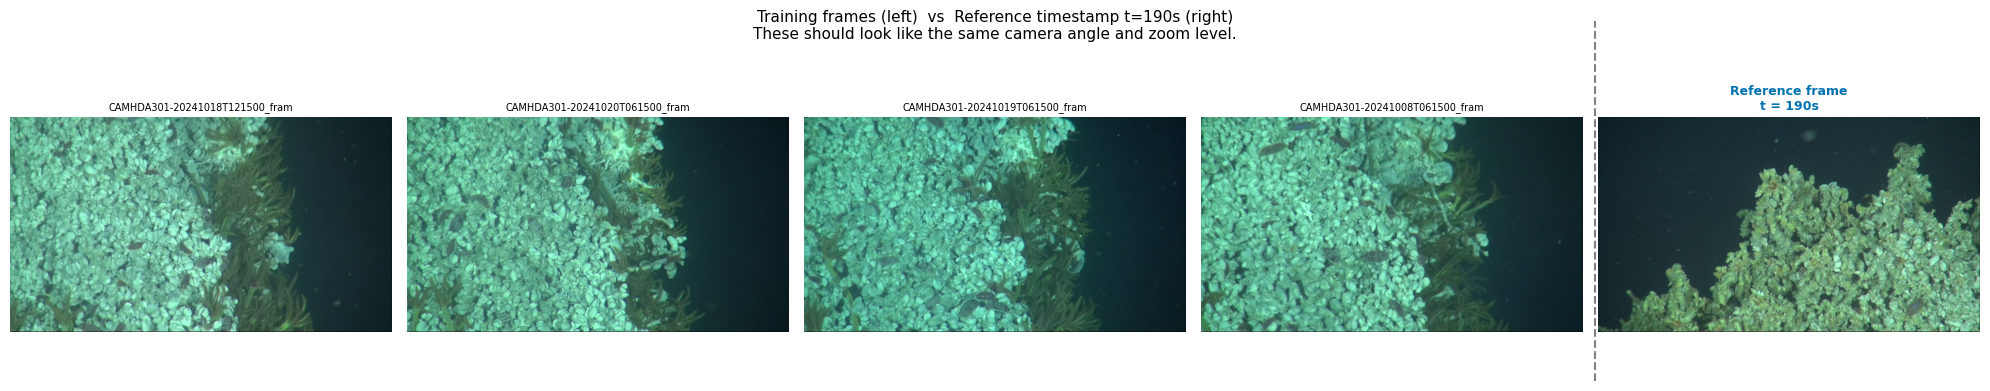


Training image directory : /home/jovyan/scaleworm-student-lab/notebooks/verification_session/export/images/train
Reference frame path     : /home/jovyan/scaleworm-student-lab/notebooks/timestamp_cache/frame_00190.png
Training frames sampled  : ['CAMHDA301-20241018T121500_frame_0007.png', 'CAMHDA301-20241020T061500_frame_0011.png', 'CAMHDA301-20241019T061500_frame_0001.png', 'CAMHDA301-20241008T061500_frame_0011.png']


In [8]:
%matplotlib inline
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# ── Configuration ─────────────────────────────────────────────────
# Change this to whatever timestamp the slider showed looked best
REFERENCE_TIMESTAMP = 190  # seconds into the video

# Training frames from round 1 — adjust path if you're on round 2
TRAIN_IMG_DIR = Path("../notebooks/verification_session/export/images/train")
if not TRAIN_IMG_DIR.exists():
    TRAIN_IMG_DIR = Path("verification_session/export/images/train")
# ─────────────────────────────────────────────────────────────────

N_SAMPLES = 4

train_frames = sorted(TRAIN_IMG_DIR.glob("*.png")) + sorted(TRAIN_IMG_DIR.glob("*.jpg"))
if len(train_frames) < N_SAMPLES:
    raise FileNotFoundError(
        f"Only {len(train_frames)} training images found in {TRAIN_IMG_DIR}. "
        "Check TRAIN_IMG_DIR path."
    )

sampled = random.sample(train_frames, N_SAMPLES)

ref_path = CACHE_DIR / f"frame_{REFERENCE_TIMESTAMP:05d}.png"
if not ref_path.exists():
    raise FileNotFoundError(
        f"No cached frame at t={REFERENCE_TIMESTAMP}s. "
        "Re-run Cell 1 or pick a timestamp that is a multiple of STEP_SEC."
    )

fig, axes = plt.subplots(1, N_SAMPLES + 1, figsize=(4 * (N_SAMPLES + 1), 4))

for ax, fp in zip(axes[:N_SAMPLES], sampled):
    ax.imshow(mpimg.imread(str(fp)))
    ax.set_title(fp.name[:30], fontsize=7)
    ax.axis("off")

axes[N_SAMPLES].imshow(mpimg.imread(str(ref_path)))
axes[N_SAMPLES].set_title(
    f"Reference frame\nt = {REFERENCE_TIMESTAMP}s",
    fontsize=9, fontweight="bold", color="#0072B2"
)
axes[N_SAMPLES].axis("off")

# Dividing line between training samples and reference
fig.add_artist(
    plt.Line2D(
        [N_SAMPLES / (N_SAMPLES + 1), N_SAMPLES / (N_SAMPLES + 1)],
        [0.05, 0.95],
        transform=fig.transFigure,
        color="gray", linewidth=1.5, linestyle="--",
    )
)

fig.suptitle(
    f"Training frames (left)  vs  Reference timestamp t={REFERENCE_TIMESTAMP}s (right)\n"
    "These should look like the same camera angle and zoom level.",
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f"\nTraining image directory : {TRAIN_IMG_DIR.resolve()}")
print(f"Reference frame path     : {ref_path.resolve()}")
print(f"Training frames sampled  : {[f.name for f in sampled]}")